# Battery Energy Storage System (BESS) Evaluation Model
[![bess.ipynb](https://img.shields.io/badge/github-%23121011.svg?logo=github)](https://github.com/ampl/colab.ampl.com/blob/master/authors/jpbohorquez/bess/bess.ipynb) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ampl/colab.ampl.com/blob/master/authors/jpbohorquez/bess/bess.ipynb) [![Open In Deepnote](https://deepnote.com/buttons/launch-in-deepnote-small.svg)](https://deepnote.com/launch?url=https://github.com/ampl/colab.ampl.com/blob/master/authors/jpbohorquez/bess/bess.ipynb) [![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ampl/colab.ampl.com/blob/master/authors/jpbohorquez/bess/bess.ipynb) [![Open In Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/ampl/colab.ampl.com/blob/master/authors/jpbohorquez/bess/bess.ipynb) [![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/ampl/colab.ampl.com/blob/master/authors/jpbohorquez/bess/bess.ipynb) [![Powered by AMPL](https://h.ampl.com/https://github.com/ampl/colab.ampl.com/blob/master/authors/jpbohorquez/bess/bess.ipynb)](https://ampl.com)

Description: This optimization model determines the optimal hourly operation of a grid-connected battery and solar PV system to maximize total value from energy savings, demand reduction, and grid services over a one-year horizon. The mixed-integer linear program captures the complex interplay between facility load, equipment constraints, and multiple revenue streams to produce a profit-maximizing operational schedule.

Tags: energy, Electric Power Industry, BESS, Battery Energy Storage System, power generation, amplpy

Notebook author: Tom Guardino <<tom@ampl.com>>, Juan Pablo Bohórquez <<juan@ampl.com>>, Mikhail Riabtsev <<mikhail@ampl.com>>

Model author: Tom Guardino <<tom@ampl.com>>, Juan Pablo Bohórquez <<juan@ampl.com>>

In [1]:
# Install dependencies
%pip install -q amplpy pandas matplotlib openpyxl

In [2]:
# Google Colab & Kaggle integration
from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["highs", "gurobi"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

## 1. Problem Description

The Battery Energy Storage System (BESS) Evaluation Model explores the case of a large industrial/commercial consumer that's considering the installation of a battery+solar PV system. It determines the optimal operation strategy for a grid-connected BESS+PV system over a one-year horizon. Acting as both a financial advisor and operations manager, the model analyzes 8,760 hourly time steps to maximize total value across multiple revenue streams while respecting all physical and operational constraints.

The model captures five distinct sources of value:
- **Energy savings.** They arise when solar generation or battery discharge replaces energy that would otherwise be purchased from the grid at retail rates. Every kilowatt-hour self-supplied avoids both the retail energy charge and the wholesale energy price embedded in the tariff.
- **Demand charge savings.** They come from the reduction of facility's monthly peak demand. The battery discharges during the hours when facility load would otherwise reach its monthly maximum, lowering the demand metric that determines a significant portion of the utility bill.
- **Coincident peak savings.** They target the single hour when the transmission or distribution grid experiences its highest annual load. The model identifies these critical hours and ensures the battery discharges specifically during those moments to reduce facility demand, avoiding substantial capacity charges.
- **Export revenue.** It captures value from selling excess solar generation to the grid at wholesale market prices when on-site consumption would yield lower returns.
- **Frequency regulation revenue.** BESS can participate in some ancillary services markets regarding frequency regulation. The battery is paid for standing ready to help balance the grid. The model allocates battery capacity to provide both "regulation up" (ready to inject power) and "regulation down" (ready to absorb power), earning payments regardless of whether the service is actually called upon.

**Physical Constraints**

All financial opportunities must respect equipment limitations. Solar production follows a time-varying profile determined by installed capacity and weather patterns. The battery operates within a maximum power rating (governing charge and discharge rates) and energy capacity (limiting total storage), with efficiency losses applied to all power flows. The state of charge must remain between minimum and maximum limits to preserve battery health, and simultaneous charging and discharging during the same period is prohibited.

The model produces a complete operational blueprint: optimal hourly charge and discharge decisions, solar export quantities, and frequency regulation capacity commitments. This schedule enables facility owners to make informed investment decisions and/or operate their systems for maximum financial return while supporting grid stability and renewable energy integration.

**System Context**

The proposed BESS system will be installed in an industrial facility within the PJM transmission system. Key model assumptions and inputs include:
- Electric load profile for an industrial facility: 785 kW peak demand.
- Solar PV system: 1,000 kW peak output.
- Electric rate tariff incorporating 5PLC and NITS costs calculated based on net facility demand during both TSO (PJM) and DSO system peak periods.
- Market prices for wholesale energy and ancillary services, specifically frequency regulation.
- BESS capital costs, operations and maintenance costs, and round-trip efficiency specifications.

**Scenarios**

The model evaluates three distinct configurations to assess the incremental value of solar integration and market participation:

| Case | BESS Configuration | Solar PV | Market Participation |
| :--- | :--- | :--- | :--- |
| **Case 1** | 500 kW / 1000 kWh | None | None |
| **Case 2** | 500 kW / 1000 kWh | Yes | Wholesale energy |
| **Case 3** | 500 kW / 1000 kWh | Yes| Wholesale energy + frequency regulation |

## 2. Mathematical Formulation


### 2.1. Sets and Indices

| **Symbol** | **Description** | **AMPL Set** |
| --- | --- | --- |
| $T$ | Set of hourly time steps in the simulation horizon (one year) |  `TIME` |
| $M$ | Set of calendar months in the year |  `MONTHS` |

### 2.2. Parameters

#### 2.2.1. Temporal Mapping

| **Symbol** | **Description** | **AMPL Parameter** |
| --- | --- | --- |
| $\tau:$ $T$ → $M$ | Function mapping each time step $t$ to its corresponding month $m$ | `time_month_map {TIME}` |

#### 2.2.2. Load and Rate Parameters

| **Symbol** | **Description** | **Unit** | **AMPL Parameter** |
| --- | --- | --- | --- |
| $L_t$ $\geq 0$ | Baseline facility load at time $t$ | kW | `site_electric_load {TIME}` |
| $RE_m$ $\geq 0$ | Retail energy rate for month $m$ | \$/kWh | `energy_rate {MONTHS}` |
| $RD_m$ $\geq 0$ | Retail demand rate for month $m$ | \$/kW | `demand_rate {MONTHS}` |


#### 2.2.3. Market Parameters

| **Symbol** | **Description** | **Unit** | **AMPL Parameter** |
| :--- | :--- | :--- | :--- |
| $ME_t$ | Electricity market energy price at time $t$ | \$/MWh | `tso_energy_price {TIME}` |
| $MR_t^{up}$ $\geq 0$ | Frequency up-regulation service price at time $t$ | \$/MWh | `tso_flex_up_price {TIME}` |
| $MR_t^{dn}$ $\geq 0$ | Frequency down-regulation service price at time $t$ | \$/MWh | `tso_flex_down_price {TIME}` |
| $RS_t^{up}$ $\in$ $[0,1]$ | Up-regulation signal (fraction of committed capacity) at time $t$ | - | `reg_d_up {TIME}` |
| $RS_t^{dn}$ $\in$ $[-1,0]$ | Down-regulation signal (negative fraction of committed capacity) at time $t$ | - | `reg_d_down {TIME}` |
| $TL_t$ $\geq 0$ | TSO aggregate system load at time $t$. Used to calculate coincident peak charges. | MW | `tso_load {TIME}` |
| $DL_t$ $\geq 0$ | DSO aggregate system load at time $t$. Used to calculate coincident peak charges. | MW | `dso_load {TIME}` |
| $RC^{TSO}$ $\geq 0$ | TSO coincident peak capacity rate | \$/kW-year | `cp_tso_rate_kw` |
| $RC^{DSO}$ $\geq 0$ | DSO coincident peak capacity rate | \$/kW-year | `cp_dso_rate_kw` |

#### 2.2.4. Battery Technical Parameters

| **Symbol** | **Description** | **Unit** | **AMPL Parameter** |
| :--- | :--- | :--- | :--- |
| $G^{batt}$ $\geq 0$ | Battery inverter capacity / maximum power rating | kW | `battery_power` |
| $S^{batt}$ $\geq 0$ | Battery storage capacity | kWh | `battery_energy` |
| $\eta$ $\in$ $[0,1]$ | Round-trip Efficiency | - | `efficiency` |
| $OM^{batt}$ $\geq 0$ | Battery fixed O&M cost | \$/kWh-year | `battery_fixed_om` |
| $Soc_0$ $\in$ $[0,1]$ | Initial state of charge (as fraction of capacity), default = 0.5 | - | `initial_soc_pct` |
| $Soc_{min}$ $\in$ $[0,1]$ | Minimum allowable state of charge (as fraction of capacity), default = 0.1 | - | `min_soc_pct` |
| $Soc_{max}$ $\in$ $[0,1]$ | Maximum allowable state of charge (as fraction of capacity), default = 0.9 | - | `max_soc_pct` |

#### 2.2.5. Solar Technical Parameters

| **Symbol** | **Description** | **Unit** | **AMPL Parameter** |
| :--- | :--- | :--- | :--- |
| $G^{sol}$ $\geq 0$ | Solar PV generation capacity | kW | `solar_capacity` |
| $U_t$ $\in$ $[0,1]$ | Solar production profile (fraction of capacity) at time $t$ | - | `solar_production_profile {TIME}` |
| $OM^{sol}$ $\geq 0$ | Solar fixed O&M cost | \$/kW-year | `solar_fixed_om` |

#### 2.2.6 Derived Parameters

**System Peak Identification**:

| **Symbol** | **Description** | **Unit** | **AMPL Parameter** |
| :--- | :--- | :--- | :--- |
| $TL^{max}$ = $\max_{t \in T}$ $TL_t$ | Maximum TSO system load | MW | `max_tso_val` |
| $t^*_{TSO}$ = $\argmax_{t \in T}$ $TL_t$ | Exact period where $TL^{max}$ is reached. | - | `max_tso_time` |
| $DL^{max}$ = $\max_{t \in T}$ $DL_t$ | Maximum DSO system load | MW | `max_dso_val` |
| $t^*_{DSO}$ = $\argmax_{t \in T}$ $DL_t$ | Exact period where $DL^{max}$ is reached. | - | `max_dso_time` |

**Monthly Baseline Peaks**:

| **Symbol** | **Description** | **Unit** | **AMPL Parameter** |
| :--- | :--- | :--- | :--- |
| $P_m^{base}$ = $\max_{t \in T}$ $L_t$, $\tau(t)$=$m$ | Facility load baseline peak for month $m$ | kW | `baseline_peak {MONTHS}` |

**Total Fixed O&M Cost**:

| **Symbol** | **Description** | **Unit** | **AMPL Parameter** |
| :--- | :--- | :--- | :--- |
| $OM^{fixed}$ = $OM^{batt}$ $\cdot$ $S^{batt}$ + $OM^{sol}$ $\cdot$ $G^{sol}$ | Annual fixed O&M cost | \$ | `OM1` |


### 2.3.1. Primary Operational Decision Variables
| **Symbol** | **Description** | **Unit** | **AMPL Variable** |
| :--- | :--- | :--- | :--- |
| $P_t$ $\geq 0$ | Solar power production at time $t$ | kW | `SolarProduction {TIME}` |
| $C_t$ $\geq 0$ | Battery charging power at time $t$ | kW | `BatteryCharge {TIME}` |
| $D_t$ $\geq 0$ | Battery discharging power at time $t$ | kW | `BatteryDischarge {TIME}` |
| $Soc_t$ | Battery state of charge at time $t$ | kWh | `Soc {TIME}` |
| $N_t$ $\geq 0$ | Net facility load after BESS and solar at time $t$ | kW | `NetLoad {TIME}` |
| $X_t$ $\geq 0$ | Power exported to the grid at time $t$ | kW | `ExportToGrid {TIME}` |

### 2.3.2. Frequency Regulation Decision Variables
| **Symbol** | **Description** | **Unit** | **AMPL Variable** |
| :--- | :--- | :--- | :--- |
| $FR_t^{up}$ $\in$ $[0,$ $G^{batt}]$ | Capacity committed to frequency upward regulation at time $t$| kW | `FlexUpBattery {TIME}` |
| $FR_t^{dn}$ $\in$ $[0,$ $G^{batt}]$| Capacity committed to frequency downward regulation at time $t$ | kW | `FlexDownBattery {TIME}` |

### 2.3.3. Auxiliary Variables
| **Symbol** | **Description** | **Unit** | **AMPL Variable** |
| :--- | :--- | :--- | :--- |
| $N_m^{peak}$ $\geq 0$ | Peak net load for month $m$. Used for demand charges. | kW | `MonthlyPeakLoad` |
| $\delta_t^{ch}$ $\in$ $[0,$ $1]$| Binary indicator: 1 if battery charging at time $t$, 0 otherwise | - | `IsCharging` |
| $\delta_t^{dis}$ $\in$ $[0,$ $1]$ | Binary indicator: 1 if battery discharging at time $t$, 0 otherwise | - | `IsDischarging` |

### 2.3.4. Revenue/Savings Component Variables
| **Symbol** | **Description** | **Unit** | **AMPL Variable** |
| :--- | :--- | :--- | :--- |
| $V^{energy}$ | Energy charge savings | \$ | `EnergyChargesSavings` |
| $V^{demand}$ | Demand charge savings | \$ | ` DemandChargesSavings` |
| $V^{CP}_{TSO}$ | TSO coincident peak savings | \$ | `CP_TSO_DemandChargesSavings` |
| $V^{CP}_{DSO}$ | DSO coincident peak savings | \$ | `CP_DSO_DemandChargesSavings` |
| $V^{export}$ | Wholesale energy market revenue | \$ | `ExportPowerValue` |
| $V^{reg}_{up}$ | Frequency up-regulation revenue | \$ | `FlexUpRevenue` |
| $V^{reg}_{dn}$ | Frequency down-regulation revenue | \$ | `FlexDownRevenue` |

### 2.4. Objective Function
Maximize net value (total savings + revenues - costs):

max($V^{energy}$ +$V^{demand}$ + $V^{CP}_{TSO}$ + $V^{CP}_{DSO}$ + $V^{export}$ + $V^{reg}_{up}$ + $V^{reg}_{dn}$ - $OM^{fixed}$)

Where:
- $V^{energy} = \sum_{t \in T} (L_t - N_t) \cdot \left( {ME_t} + RE_{\tau(t)} \right)$
- $V^{demand} = \sum_{m \in M} (P_m^{base} - N_m^{peak}) \cdot RD_m$
- $V^{CP}_{TSO} = \sum_{t \in {T:t=t^*_{TSO}}}12 \cdot RC^{TSO} \cdot (L_t - N_t)$
- $V^{CP}_{DSO} = \sum_{t \in {T:t=t^*_{DSO}}}12 \cdot RC^{DSO} \cdot (L_t - N_t)$
- $V^{export} = \sum_{t \in T} {X_t \cdot ME_t}$
- $V^{reg}{up} = \sum_{t \in T} {FR_t^{up} \cdot MR_t^{up}}$
- $V^{reg}{dn} = \sum_{t \in T} {FR_t^{dn} \cdot MR_t^{dn}}$

**Note:** Some market prices are adjusted (divided by 1000) in the model implementation so units are treated correctly.

### 2.5. Constraints
#### 2.5.1 Battery Operational State
Either charging or discharging for a certain period.
- $\delta_t^{ch} + \delta_t^{dis} \leq 1, \quad \forall t \in T$

#### 2.5.2 Solar Generation
Follows solar hourly profile.
- $P_t = U_t \cdot G^{sol}, \quad \forall t \in T$

#### 2.5.3 Battery Power Limits
- $C_t \leq G^{batt} \cdot \delta_t^{ch}, \quad \forall t \in T$
- $D_t \leq G^{batt} \cdot \delta_t^{dis}, \quad \forall t \in T$

#### 2.5.4 Regulation Capacity Limits (State of Charge Feasibility)
- $FR_t^{up} \leq ( Soc_{t-1} - Soc_{min} \cdot S^{batt}) \cdot \sqrt{\eta}, \quad \forall t \in T$
- $FR_t^{dw} \leq \frac{Soc_{max} \cdot S^{batt} - Soc_{t-1}}{\sqrt{\eta}}, \quad \forall t \in T$

Where $Soc_0$ is defined as $Soc_0 \cdot S^{batt}$.

#### 2.5.5 State of Charge Dynamics
- $Soc_t = Soc_{t-1} + \sqrt{\eta} \cdot C_t - \frac{D_t}{\sqrt{\eta}}, \quad \forall t \in T$

With initial condition: $Soc_0 = Soc_0 \cdot S^{batt}$

#### 2.5.6 Energy Capacity Limit
- $Soc_t \leq S^{batt}, \quad \forall t \in T$

#### 2.5.7 Net Load Definition
- $N_t = L_t - P_t - D_t + C_t + X_t, \quad \forall t \in T$

#### 2.5.8 Regulation Signal Compliance
- $D_t \geq RS_t^{up} \cdot FR_t^{up}, \quad \forall t \in T$
- $C_t \geq -RS_t^{dn} \cdot FR_t^{dn}, \quad \forall t \in T$

#### 2.5.9 Peak Load Tracking
- $N_m^{peak} \geq N_t, \quad \forall m \in M, t \in T: \tau(t) = m$

#### 2.5.10 Export Limit
- $X_t \leq P_t, \quad \forall t \in T$

### 2.6. Key Modeling Assumptions
For the studied cases, it's relevant to note the following assumptions:
- **Perfect foresight:** All prices, loads, and signals are known in advance.
- **Linear efficiency:** Battery round-trip losses modeled via constant efficiency parameter.
- **No degradation:** Battery performance assumed constant over the one year analysis period. Should a longer time horizon be modeled, this would have to be considered.
- **Hourly resolution:** All dynamics captured at hourly intervals.
- **No simultaneous regulation:** Battery cannot provide both up and down regulation in the same hour.
- **Peak coincidence:** Single-hour peaks for TSO and DSO systems.
- **No export from battery:** Exports limited to solar generation only (model includes commented option to allow exporting battery discharges).

## 3. AMPL Implementation
The model explained above is implemented using AMPL in this section.

In [3]:
%%writefile BESS.mod

set TIME ordered;                       # Set of hours in the simulation (1..8760)
set MONTHS;                             # Set of months

# ----------------------------------------------------------------------------
# PARAMETERS
# ----------------------------------------------------------------------------

# Mapping parameter to link time steps to rate periods
param time_month_map {TIME} within MONTHS;

# Load and Rates
param site_electric_load {TIME} >= 0;   # Baseline facility load (kW) [Symbol: L]
param energy_rate {MONTHS} >= 0;        # Retail energy rate ($/kWh) [Symbol: RE]
param demand_rate {MONTHS} >= 0;        # Retail demand rate ($/kW) [Symbol: RD]

# Market Prices and Signals
param tso_energy_price {TIME};          # Electricity market price ($/MWh) [Symbol: ME]
param tso_flex_up_price {TIME} >= 0;    # Freq regulation market price ($/MWh) [Symbol: MR]
param tso_flex_down_price {TIME} >= 0;  # Freq regulation market price for regulation down ($/MWh) [Symbol: MR_DN]
param reg_d_up {TIME};        # Freq reg signal for increased supply (%) [Symbol: RS_U]
param reg_d_down {TIME};      # Freq reg signal for decreased supply (%) [Symbol: RS_D]
param tso_load {TIME} >= 0;             # Aggregate demand for TSO (MW) [Symbol: TL]
param dso_load {TIME} >= 0;             # Aggregate demand for DSO (MW) [Symbol: DL]
param cp_tso_rate_kw >= 0;              # Coincident peak capacity rate ($/kW) [Symbol: RC]
param cp_dso_rate_kw >= 0;              # Coincident peak capacity rate for DSO (if applicable) ($/kW) [Symbol: RC_DSO]

# Battery Technical Specs
param battery_power >= 0;               # Inverter capacity/Max rate (kW) [Symbol: Gbattery]
param battery_energy >= 0;              # Storage capacity (kWh) [Symbol: Sbattery]
param efficiency >= 0, <= 1;            # Battery efficiency (%) [Symbol: E]
param battery_fixed_om >= 0;            # Battery O&M costs ($/kWh-year) [Symbol: OMbattery]
param initial_soc_pct >= 0, <= 1, default 0.5;  # Initial state of charge (kWh) [Symbol: Soc0]
param min_soc_pct >= 0, <= 1, default 0.1;      # Minimum state of charge as % of capacity (kWh) [Symbol: MinSoc]
param max_soc_pct >= 0, <= 1, default 0.9;

# Solar Technical Specs
param solar_capacity >= 0;              # Solar generation capacity (kW) [Symbol: Gsolar]
param solar_production_profile {TIME} >= 0; # Solar production per unit capacity (%) [Symbol: U]
param solar_fixed_om >= 0;              # Solar O&M costs ($/kW-year) [Symbol: OMsolar]

# Coincident Peak Identification
# Find the max TSO load to identify t*
param max_tso_val = max {t in TIME} tso_load[t];
param max_tso_time = max {t in TIME: tso_load[t] = max_tso_val} t;  # Only count 1 hour for the coincident peak, not every hour where max demand happens

param max_dso_val = max {t in TIME} dso_load[t];
param max_dso_time = max {t in TIME: dso_load[t] = max_dso_val} t;  # Only count 1 hour for the coincident peak, not every hour where max demand happens

# Baseline peak parameter for each month
param baseline_peak {m in MONTHS} = max {t in TIME: time_month_map[t] = m} site_electric_load[t];

# Operating and Maintenance Costs
# OM1 = Fixed costs (Battery + Solar)
param OM1 = (battery_fixed_om * battery_energy) + (solar_fixed_om * solar_capacity);

# ----------------------------------------------------------------------------
# DECISION VARIABLES
# ----------------------------------------------------------------------------

var SolarProduction {TIME} >= 0;    # Solar electricity production (kW) [Symbol: P]
var BatteryCharge {TIME} >= 0;      # BESS electric charge (kW) [Symbol: C]
var BatteryDischarge {TIME} >= 0;   # BESS electric discharge (kW) [Symbol: D]
var Soc {TIME} >= min_soc_pct * battery_energy, <= max_soc_pct * battery_energy;                     # BESS state of charge (kWh) [Symbol: Soc]
var NetLoad {TIME} >= 0;            # Net facility load after BESS/Solar (kW) [Symbol: N]
var ExportToGrid {TIME} >= 0;       # Surplus solar production exported (kW) [Symbol: X]
var FlexUpBattery {TIME} >= 0, <= battery_power;         # BESS capacity participating in Freq Reg (kW) [Symbol: FR]
var FlexDownBattery {TIME} >= 0, <= battery_power;       # BESS capacity participating in Freq Reg for regulation down (kW) [Symbol: FR_DN]

# Auxiliary variables for peak tracking (Required for Demand Charge Savings)
var PeakNetLoad {MONTHS} >= 0;      # Max net load per month

var BatteryCharging {TIME} binary;  # Binary variable to indicate if battery is charging (1) or discharging (0) at time t
var BatteryDischarging {TIME} binary;   # Binary variable to indicate if battery is discharging (1) or charging (0) at time t

# -----
# Other variables (savings and revenues) for objective function
# -----

# Energy Charge Savings
# E1 = Sum((Lt - Nt) * RE)
var EnergyChargesSavings = sum {t in TIME} (site_electric_load[t] - NetLoad[t]) * (tso_energy_price[t]/1000 + energy_rate[time_month_map[t]]);

# Demand Charge Savings
# D1 = Sum((Max(L) - Max(N)) * RD)
var DemandChargesSavings = sum {m in MONTHS} (baseline_peak[m] - PeakNetLoad[m]) * demand_rate[m];

# Coincident Peak Charge Savings
# CP1 = RC * (Lt* - Nt*)
var CP_TSO_DemandChargesSavings =
    sum {t in TIME: t = max_tso_time} 12*(cp_tso_rate_kw * (site_electric_load[t] - NetLoad[t]));

# Coincident Peak Charge Savings for DSO
# CP2 = RC_DSO * (Dt* - Nt*)
var CP_DSO_DemandChargesSavings =
    sum {t in TIME: t = max_dso_time} 12*(cp_dso_rate_kw * (site_electric_load[t] - NetLoad[t]));

# Wholesale Energy Market Revenues
# M1 = Sum(Xt * MEt)
var ExportPowerValue = sum {t in TIME} (ExportToGrid[t] * tso_energy_price[t])/1000;

# Frequency Regulation Market Revenues
# FR1 = Sum(FRt * MRt)
var FlexUpRevenue = sum {t in TIME} (FlexUpBattery[t] * tso_flex_up_price[t])/1000;
# FR2 = Sum(FR_DNt * MR_DNt)
var FlexDownRevenue = sum {t in TIME} (FlexDownBattery[t] * tso_flex_down_price[t])/1000;


# ----------------------------------------------------------------------------
# OBJECTIVE FUNCTION
# ----------------------------------------------------------------------------

# V1 = E1 + D1 + CP1 + M1 + FR1 - OM1
maximize NetValue:
    EnergyChargesSavings +
    DemandChargesSavings +
    CP_TSO_DemandChargesSavings +
    CP_DSO_DemandChargesSavings +
    ExportPowerValue +
    FlexUpRevenue +
    FlexDownRevenue -
    OM1;

# ----------------------------------------------------------------------------
# OPERATING CONSTRAINTS
# ----------------------------------------------------------------------------

subject to Exclusive_State {t in TIME}:
    BatteryCharging[t] + BatteryDischarging[t] <= 1;

# Solar Production
subject to SolarGenDef {t in TIME}:
    SolarProduction[t] = solar_production_profile[t] * solar_capacity;

# Battery Power Capacity
subject to ChargeLimit {t in TIME}:
    BatteryCharge[t] <= battery_power * BatteryCharging[t];

subject to DischargeLimit {t in TIME}:
    BatteryDischarge[t] <= battery_power * BatteryDischarging[t];

subject to FlexUpLimit {t in TIME}:
    FlexUpBattery[t] <= ((if ord(t) > 1 then Soc[t-1] else initial_soc_pct * battery_energy) - min_soc_pct * battery_energy) / (efficiency^0.5);

subject to FlexDownLimit {t in TIME}:
    FlexDownBattery[t] <= (max_soc_pct * battery_energy - (if ord(t) > 1 then Soc[t-1] else initial_soc_pct * battery_energy)) * (efficiency^0.5);

# Battery State of Charge limits
subject to SocCapacity {t in TIME}:
    Soc[t] <= battery_energy;

# Battery Continuity Balance
subject to SocBalance {t in TIME}:
    Soc[t] = (if ord(t) > 1 then Soc[t-1] else initial_soc_pct * battery_energy)
             + ((efficiency^0.5)* BatteryCharge[t])
             - (BatteryDischarge[t] / (efficiency^0.5));

# Net Electric Load
# Nt = Lt - Pt - Dt + Ct + Xt
subject to NetLoadDef {t in TIME}:
    NetLoad[t] = site_electric_load[t]
                  - SolarProduction[t]
                  - BatteryDischarge[t]
                  + BatteryCharge[t]
                  + ExportToGrid[t];

# Frequency Regulation Participation
# Discharge must meet Up signal * Committed Capacity
subject to RegUpConstraint {t in TIME}:
    BatteryDischarge[t] >= reg_d_up[t] * FlexUpBattery[t];

# Charge must meet Down signal * Committed Capacity
subject to RegDownConstraint {t in TIME}:
    BatteryCharge[t] >= -reg_d_down[t] * FlexDownBattery[t];

# Define Peak Tracking for Demand Charges
# PeakNetLoad must be at least the NetLoad in that month
subject to PeakTracking {m in MONTHS, t in TIME: time_month_map[t] = m}:
    PeakNetLoad[m] >= NetLoad[t];

# Limit exports to onsite generation (Solar + Battery Discharge)
subject to ExportLimit {t in TIME}:
    ExportToGrid[t] <= SolarProduction[t];#+ BatteryDischarge[t];

Writing BESS.mod


## 4. Code

This section presents a few convenience python functions that seek to accomplish the following:

* Read the data and load it into the model.
* Solve using specific AMPL options or solver parameters.
* Fetch solution or manage optimization result.
* Plot results for further analysis.

To that end, pandas and matplotlib libraries are imported to handle data manipulation and visualization respectively.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### 4.1 Load data

In [5]:
def load_data_to_model(ampl, case=1, data_file="bess_input.xlsx"):
    """
    This function loads data into the AMPL model and adjusts it based on the selected case.

    Parameters:
    - ampl (AMPL): The AMPL object to which the data will be loaded.
    - case (int): The case number to determine the adjustments to the data.
        - Case 1: No solar, no market participation.
        - Case 2: With solar, no frequency regulation.
        - Case 3: With solar, with market participation.
    - data_file (str): The path to the Excel file containing the input data.

    The function performs the following steps:
    1. Reads the input data from the specified Excel file.
    2. Loads time-series and rate data into the AMPL model.
    3. Sets additional parameters for the model from the input data.
    4. Adjusts the model data based on the selected case:
         - Case 1: Disables solar production and market participation.
         - Case 2: Enables solar production and wholesale market but disables frequency regulation participation.
         - Case 3: Enables both solar production and market participation.
    5. Resets the model if an unrecognized case is provided.
    """
    # Adjusting path for colab
    data_file = f"https://raw.githubusercontent.com/ampl/colab.ampl.com/master/authors/jpbohorquez/bess/{data_file}"

    # Read the file
    dct_case1 = pd.read_excel(data_file, sheet_name=None)
    df_time_series = dct_case1["Time_Series"]
    df_rates = dct_case1["Rates"]
    df_cp_programs = dct_case1["CP_Programs"]
    df_battery = dct_case1["Battery"]
    df_solar = dct_case1["Solar"]

    # Set the data
    ampl.set_data(
        df_time_series.drop(
            columns=["weekday_type", "hour", "date_time", "date", "day_of_year"]
        ).set_index("TIME"),
        set_name="TIME",
    )
    ampl.set_data(df_rates.set_index("MONTHS"), set_name="MONTHS")

    dct_params = df_cp_programs.to_dict(orient="index")[0]
    dct_params.update(df_battery.to_dict(orient="index")[0])
    dct_params.update(df_solar.to_dict(orient="index")[0])

    for k, v in dct_params.items():
        ampl.param[k] = v

    # Adjust data based on selected case
    if case == 1:
        print("Case 1: No solar, no market participation")
        # No solar
        ampl.param["solar_capacity"] = 0
        ampl.eval("fix {t in TIME} SolarProduction[t] := 0;")
        # No market
        ampl.eval("fix {t in TIME} ExportToGrid[t] := 0;")
        ampl.eval("fix {t in TIME} FlexUpBattery[t] := 0;")
        ampl.eval("fix {t in TIME} FlexDownBattery[t] := 0;")
    elif case == 2:
        print("Case 2: With solar, no frequency regulation")
        # No Freq market
        ampl.eval("fix {t in TIME} FlexUpBattery[t] := 0;")
        ampl.eval("fix {t in TIME} FlexDownBattery[t] := 0;")
    elif case == 3:
        print("Case 3: With solar, with full market participation")
        # No adjustments needed
    else:
        print(f"Case {case} not recognized.")
        ampl.reset()  # Reset any previous adjustments

### 4.2 Solve problem

In [6]:
def solve_model(ampl, case=1, verbose=False, **kwargs):
    """
    This function solves the BESS optimization model for a given case and solver options.

    Parameters:
    - ampl (AMPL): The AMPL object to interact with the optimization model.
    - case (int): The case number to determine the adjustments to the data.
        - Case 1: No solar, no market participation.
        - Case 2: With solar, no frequency regulation.
        - Case 3: With solar, with market participation.
    - verbose (bool): If True, prints detailed solver output.
    - kwargs (dict): Additional solver options to be passed to the AMPL model.

    Steps:
    1. Resets the AMPL environment and loads the model file.
    2. Loads the data into the model based on the selected case.
    3. Sets solver options provided in `kwargs`.
    4. Solves the optimization problem.
    5. Prints the total net value if the optimization is successful, or an error message otherwise.

    Returns:
    - None
    """
    ampl.reset()
    ampl.read("BESS.mod")

    load_data_to_model(ampl, case=case)

    ampl.eval("reset options;")
    for k, v in kwargs.items():
        ampl.set_option(k, v)
    ampl.solve(verbose=verbose)

    if ampl.solve_result == "solved":
        objective = ampl.get_objective("NetValue").value()
        print(f"Total net value (Case {case}): {objective:,.2f} USD.")
    else:
        print(f"Optimization failed with status: {ampl.solve_result}")

### 4.3 Retrieve solution

In [7]:
def process_results(ampl, case=1, export_results=False):
    """
    This function processes the results of the optimization model and optionally exports them to an Excel file.

    Parameters:
    - ampl (AMPL): The AMPL object containing the optimization model and results.
    - case (int): The case number to include in the exported file name.
    - export_results (bool): If True, exports the solution to an Excel file.

    Steps:
    1. Checks if the optimization problem was solved successfully.
    2. If `export_results` is True, exports the full solution to an Excel file named `case{case}_solution.xlsx`.
    3. Retrieves time-series data for key variables and converts it to a pandas DataFrame.
    4. Retrieves objective function components and their values as a dictionary.
    5. Retrieves monthly peak load data and converts it to a pandas DataFrame.

    Returns:
    - df_period (pd.DataFrame): Time-series data for key variables.
    - dct_objective (dict): Objective function components and their values.
    - df_month (pd.DataFrame): Monthly peak load data.

    If the optimization problem fails, the function prints an error message and returns None for all outputs.
    """
    if ampl.solve_result == "solved":

        if export_results:
            df = pd.DataFrame.from_dict(ampl.get_solution(flat=False, zeros=True))
            df.to_excel(f"case{case}_solution.xlsx")
            print(f"Results exported to case{case}_solution.xlsx")

        df_period = (
            ampl.get_data(
                """
                                  site_electric_load,
                                  SolarProduction,
                                  BatteryCharge,
                                  BatteryDischarge,
                                  ExportToGrid,
                                  NetLoad,
                                  FlexUpBattery,
                                  FlexDownBattery,
                                  {t in TIME} Soc[t]/battery_energy,
                                  {t in TIME} tso_energy_price[t] + energy_rate[time_month_map[t]]*1000;
                                """
            )
            .to_pandas()
            .reset_index(names=["period"])
        )
        df_period.columns = [
            "period",
            "Baseline Load",
            "Solar Production",
            "Battery Charge",
            "Battery Discharge",
            "Export to Grid",
            "Import from Grid",
            "Flex Up Battery",
            "Flex Down Battery",
            "State of Charge (%)",
            "Energy Rate ($/MWh)",
        ]

        dct_objective = (
            ampl.get_data(
                """
                                    NetValue,
                                    EnergyChargesSavings,
                                    DemandChargesSavings, 
                                    CP_TSO_DemandChargesSavings,
                                    CP_DSO_DemandChargesSavings, 
                                    ExportPowerValue,
                                    FlexUpRevenue,
                                    FlexDownRevenue, 
                                    OM1
                                    """
            )
            .to_pandas()
            .to_dict(orient="records")[0]
        )

        df_month = (
            ampl.get_data(
                """
                                    baseline_peak,
                                    PeakNetLoad
                                     """
            )
            .to_pandas()
            .reset_index(names=["month"])
        )

        return df_period, dct_objective, df_month
    else:
        print(
            f"Cannot process results because optimization failed with status: {ampl.solve_result}"
        )
        return None, None, None

### 4.4 Plotting

In [8]:
def plot_power_balance(df, date_range, case=1):
    """
    This function visualizes the effects of the BESS system on the site load over a specified date range.

    Parameters:
    - df (pd.DataFrame): A DataFrame containing time-series data for key variables, including baseline load,
        solar production, battery charge/discharge, net load, and energy rate.
    - date_range (tuple): A tuple specifying the start and end days of the year to visualize (inclusive).
    - case (int): The case number to include in the plot titles.

    Steps:
    1. Filters the DataFrame for the specified date range.
    2. Creates a two-panel plot:
         - The top panel shows the power balance, including baseline load, imports from the grid, solar production,
             battery charge/discharge, and exports to the grid. It also overlays the net load and energy price.
         - The bottom panel shows the battery's state of charge (SOC) as a percentage.
    3. Adds legends, labels, and gridlines for clarity.
    4. Displays the plot.

    Returns:
    - None
    """
    # Filter the dataframe for the specified date range
    start_hour = (date_range[0] - 1) * 24 + 1
    end_hour = date_range[1] * 24
    df_filtered = df[(df["period"] >= start_hour) & (df["period"] <= end_hour)]

    # Create the figure and subplots
    fig, axs = plt.subplots(
        2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )

    # Top chart: Power balance
    ax1 = axs[0]
    ax1.plot(
        df_filtered["period"],
        df_filtered["Baseline Load"],
        label="Baseline Load",
        color="black",
        linestyle="--",
    )
    ax1.fill_between(
        df_filtered["period"],
        0,
        df_filtered["Import from Grid"],
        label="Imports from Grid",
        color="gray",
        alpha=0.5,
    )
    if case > 1:
        ax1.fill_between(
            df_filtered["period"],
            df_filtered["Import from Grid"],
            df_filtered["Import from Grid"] + df_filtered["Solar Production"],
            label="Solar Production",
            color="yellow",
            alpha=0.5,
        )
    ax1.fill_between(
        df_filtered["period"],
        df_filtered["Import from Grid"] + df_filtered["Solar Production"],
        df_filtered["Import from Grid"]
        + df_filtered["Solar Production"]
        + df_filtered["Battery Discharge"],
        label="Battery Discharge",
        color="green",
        alpha=0.5,
    )
    ax1.fill_between(
        df_filtered["period"],
        -df_filtered["Battery Charge"],
        0,
        label="Battery Charging",
        color="orange",
        alpha=0.5,
    )
    ax1.fill_between(
        df_filtered["period"],
        -df_filtered["Battery Charge"] - df_filtered["Export to Grid"],
        -df_filtered["Battery Charge"],
        label="Exports to Grid",
        color="red",
        alpha=0.5,
    )
    ax1.plot(
        df_filtered["period"],
        df_filtered["Import from Grid"],
        color="black",
        linestyle="-",
    )

    ax1.set_ylabel("Power (kW)")
    ax1.set_title(f"Power Balance Chart - Case {case}")
    ax1.legend(loc="upper left")
    ax1.grid(True)

    # Add a second y-axis for energy price
    ax2 = ax1.twinx()
    ax2.plot(
        df_filtered["period"],
        df_filtered["Energy Rate ($/MWh)"],
        label="Energy Price",
        color="purple",
        linestyle=":",
    )
    ax2.set_ylabel("Energy Price ($/MWh)", color="purple")
    ax2.tick_params(axis="y", labelcolor="purple")
    # ax2.set_ylim(bottom=-20)
    ax2.legend(loc="upper right")

    # Bottom chart: State of Charge (with percentage formatting)
    axs[1].plot(
        df_filtered["period"],
        df_filtered["State of Charge (%)"] * 100,
        label="State of Charge (SOC)",
        color="purple",
    )
    axs[1].set_ylabel("SOC (%)")
    axs[1].set_title(f"Battery State of Charge - Case {case}")
    axs[1].legend(loc="upper right")
    axs[1].grid(True)

    # Shared x-axis
    axs[1].set_xlabel("Hour of the Year")
    plt.tight_layout()
    plt.show()

## 5. Execution and Visualization

This section runs the previously defined functions and discuss the results obtained for every case. It's important to note that a different day range (from 1 to 365) can be chosen to adjust the charts. Furthermore, since case 3 is more computationally expensive, a less strict mipgap is used and commercial solvers are suggested. Gurobi is used and tuned for this case with a 10% mipgap.

In [9]:
options = {"solver": "highs", "mp_options": "outlev=1 mipgap=0.01"}

In [10]:
solve_model(ampl, case=1, verbose=True, **options)

Case 1: No solar, no market participation
HiGHS 1.11.0:   tech:outlev = 1
  mip:gap = 0.01

AMPL MP initial flat model has 52572 variables (0 integer, 17520 binary);
Objectives: 1 linear; 
Constraints:  52560 linear;

AMPL MP did not modify the model.


Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
MIP  has 52560 rows; 52573 cols; 131399 nonzeros; 17520 integer variables (17520 binary)
Coefficient ranges:
  Matrix [9e-01, 5e+02]
  Cost   [3e-02, 1e+02]
  Bound  [1e+00, 5e+05]
  RHS    [1e+00, 8e+02]
Presolving model
52560 rows, 52572 cols, 131399 nonzeros  0s
43800 rows, 43812 cols, 113879 nonzeros  0s
43800 rows, 43812 cols, 113879 nonzeros  0s

Solving MIP model with:
   43800 rows
   43812 cols (8760 binary, 0 integer, 0 implied int., 35052 continuous, 0 domain fixed)
   113879 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; J => Feasibility jump;
     H => Heuristic; L => Sub-MIP; P => Empty MIP; R => Randomi

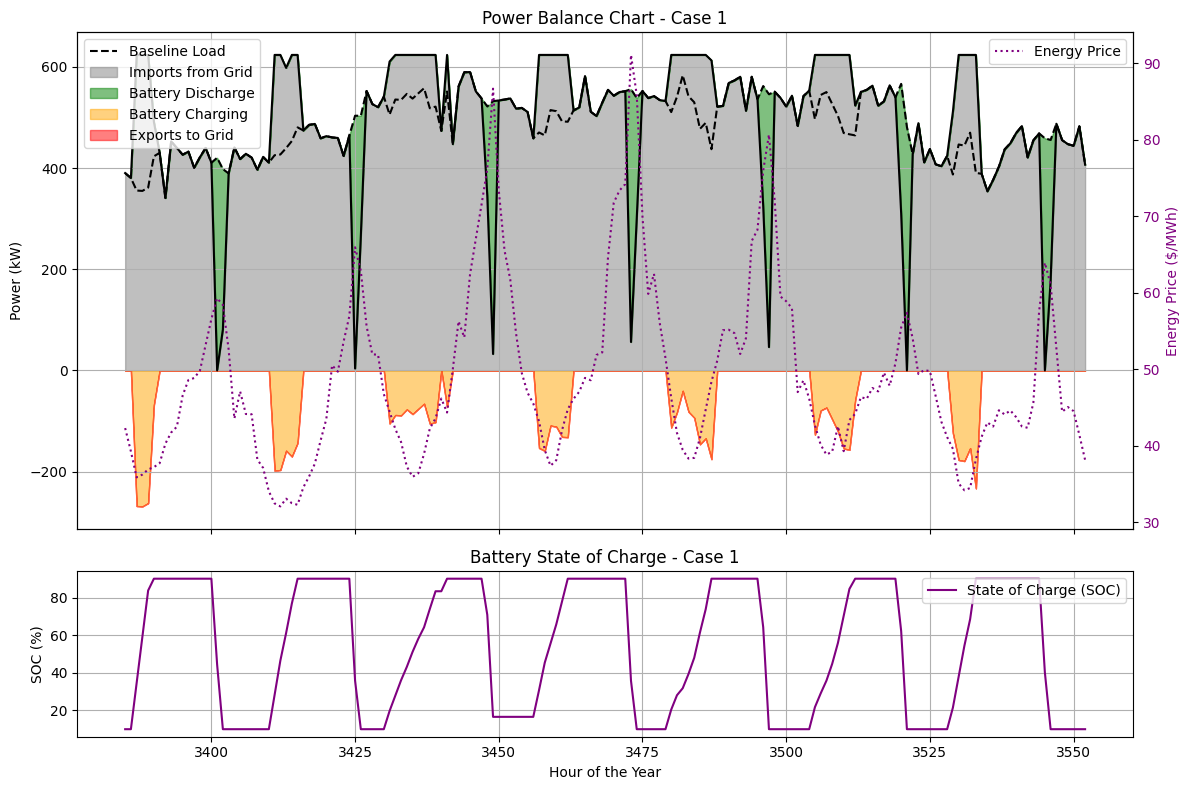

In [11]:
df_period_case_1, dct_objective_case_1, df_month_case_1 = process_results(ampl)
plot_power_balance(df_period_case_1, date_range=(142, 148), case=1)

In [12]:
solve_model(ampl, case=2, verbose=True, **options)

Case 2: With solar, no frequency regulation
HiGHS 1.11.0:   tech:outlev = 1
  mip:gap = 0.01

AMPL MP initial flat model has 56747 variables (0 integer, 17520 binary);
Objectives: 1 linear; 
Constraints:  52560 linear;

AMPL MP did not modify the model.


Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
MIP  has 52560 rows; 56748 cols; 135574 nonzeros; 17520 integer variables (17520 binary)
Coefficient ranges:
  Matrix [9e-01, 5e+02]
  Cost   [7e-03, 1e+02]
  Bound  [1e-02, 4e+05]
  RHS    [6e-02, 8e+02]
Presolving model
52560 rows, 56747 cols, 135574 nonzeros  0s
43800 rows, 47987 cols, 118054 nonzeros  0s
43800 rows, 47987 cols, 118054 nonzeros  0s

Solving MIP model with:
   43800 rows
   47987 cols (8760 binary, 0 integer, 0 implied int., 39227 continuous, 0 domain fixed)
   118054 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; J => Feasibility jump;
     H => Heuristic; L => Sub-MIP; P => Empty MIP; R => Rando

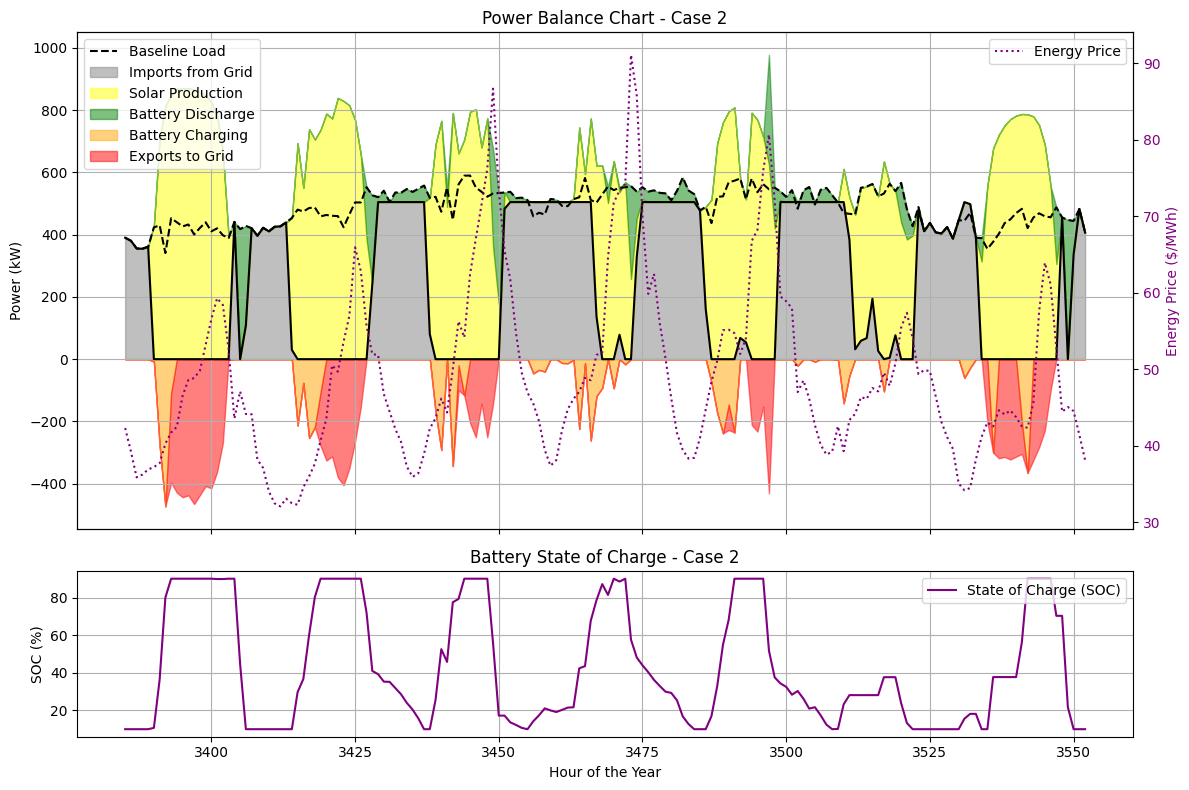

In [13]:
df_period_case_2, dct_objective_case_2, df_month_case_2 = process_results(ampl)
plot_power_balance(df_period_case_2, date_range=(142, 148), case=2)

In [14]:
options = {
    "solver": "gurobi",
    "mp_options": "outlev=1 mipgap=0.1 mipfocus=2 cutpasses=5 cuts=2 varbranch=3",
}
solve_model(ampl, case=3, verbose=True, **options)

Case 3: With solar, with full market participation
Gurobi 13.0.0: Set parameter LogToConsole to value 1
  tech:outlev = 1
Set parameter MIPGap to value 0.1
  mip:gap = 0.10000000000000001
Set parameter MIPFocus to value 2
  mip:focus = 2
Set parameter CutPasses to value 5
  cut:passes = 5
Set parameter Cuts to value 2
  cut:cuts = 2
Set parameter VarBranch to value 3
  mip:varbranch = 3

AMPL MP initial flat model has 74267 variables (0 integer, 17520 binary);
Objectives: 1 linear; 
Constraints:  87597 linear;

AMPL MP final model has 74268 variables (0 integer, 17520 binary);
Objectives: 1 linear; 
Constraints:  87597 linear;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.3.0 25D125)

CPU model: Apple M5
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
MIPGap  0.1
MIPFocus  2
VarBranch  3
Cuts  2
CutPasses  5
InfUnbdInfo  1

Optimize a model with 87597 rows, 74268 co

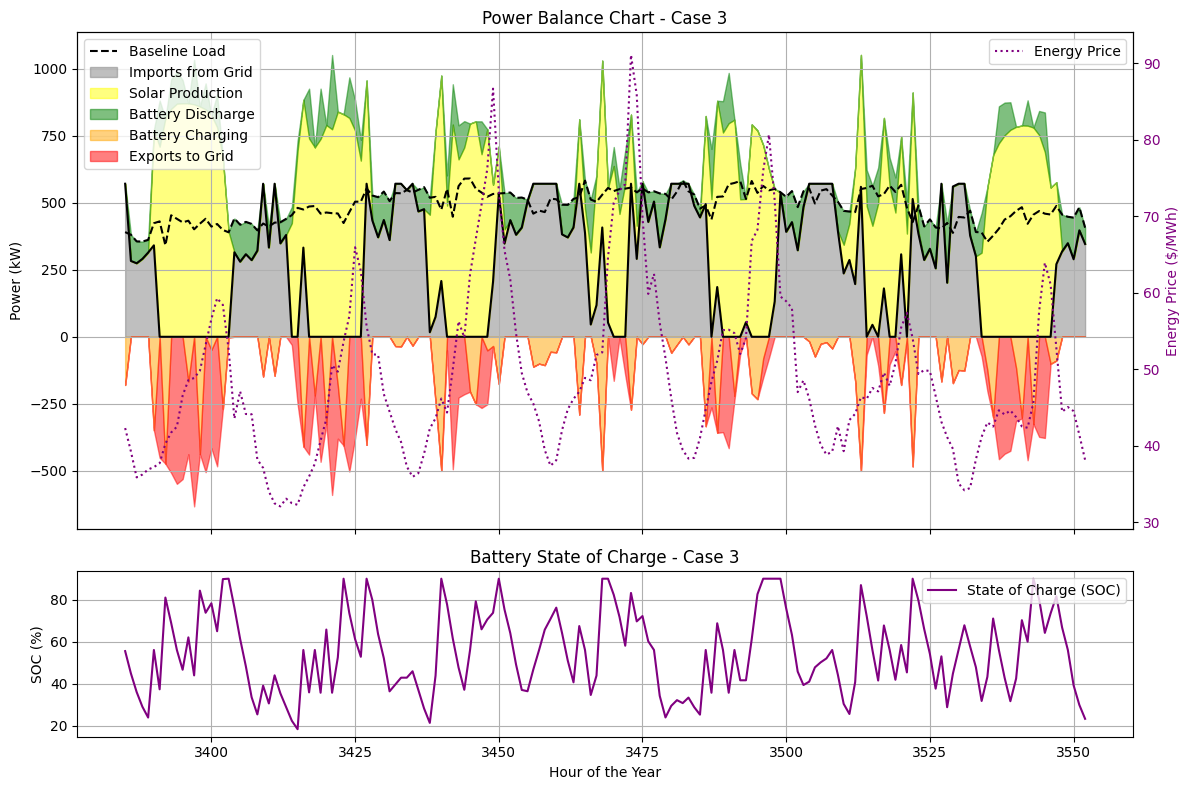

In [15]:
df_period_case_3, dct_objective_case_3, df_month_case_3 = process_results(ampl)
plot_power_balance(df_period_case_3, date_range=(142, 148), case=3)

### 5.1. Results Discussion

This section discusses the operational results of the BESS optimization model across three distinct use cases. The results validate the model's logic while highlighting trade-offs between granularity, market participation, and computational efficiency.

**Arbitrage and Solar Integration (Case 1 & 2)**

The model demonstrates intuitive economic behavior in the first two cases. In Case 1 (Battery Only), the battery consistently charges during periods of lowest energy prices and discharges during peak price intervals, effectively capturing price spreads to minimize costs.

In Case 2 (Solar + Battery), this behavior evolves to leverage onsite generation. When solar production is high and grid prices are attractive, the model prioritizes exporting excess solar energy to the grid rather than storing it, maximizing immediate revenue. Conversely, during low-price periods, solar energy is used to charge the battery or offset the baseline load, avoiding import costs. This dynamic is visualized above, where battery dispatch (green) aligns with price peaks (purple dashed line) and solar exports (yellow/red).

**Impact of Frequency Regulation (Case 2 vs. Case 3)**

Comparing the same operational days in Case 2 and Case 3 (+Frequency Regulation) reveals a distinct change in battery utilization. In Case 3, the BESS is significantly more active, with frequent, shallow charge and discharge cycles driven by regulation signals. This increased throughput demonstrates the model’s ability to stack revenue streams: while the battery still performs energy arbitrage, it sacrifices some capacity to provide regulation services, resulting in higher total utilization and potential revenue, albeit with increased cycling aging.

**Model Granularity and Computational Efficiency**

The current results are based on hourly interval data. However, the model architecture is agnostic to time-step duration. It can be easily adjusted to process *15-minute or 5-minute intervals* to capture faster ramp rates or sub-hourly pricing spikes. It is important to note that increasing temporal resolution directly increases the number of decision variables, which may impact computational efficiency and solve times for annual simulations.

**Peak Shaving Uncertainty**

To enhance the realism of peak shaving strategies, the current perfect-foresight approach can be modified. In real-world operations, the exact hour of peak demand is often unknown until it has already passed. An additional constraint can be introduced to force battery discharge not just during the predicted peak hour, but also during the *intervals immediately preceding and following it*. This "shoulder" discharge strategy acts as a safety buffer, ensuring demand charges are mitigated even if the actual peak shifts slightly from the forecast. This would be very easy to implement considering AMPL ordered sets capabilities.

**Solar Sizing**

Currently, the PV system size is fixed prior to optimization. To allow the model to optimally size the solar array dynamically, parameter `solar_capacity` would have to be defined as a decision variable. This would allow the optimizer to trade off capital expenditure against operational savings.

**Operations & Maintenance (O&M) Costs**

For simplicity, this analysis included only *fixed O&M costs*, which act as a constant adder and do not influence the dispatch logic. However, the model can be readily expanded to include *variable O&M (VOM) costs*, typically denominated in $/MWh of throughput. Introducing VOM would add a marginal cost to every charge/discharge cycle, potentially reducing battery activity in marginal arbitrage scenarios where the price spread is smaller than the VOM cost.

## 6. Model Applications
The model described above is a simplified version of the BESS Evaluation Model, which is designed to illustrate the core capabilities of the model.  It is a subset of a more general model framework that has been customized in numerous applications to evaluate a broad range of BESS deployment strategies and market scenarios.  

These include:

- **Diverse commercial / industrial facilities**.  BESS opportunities for a given facility depend on numerous factors, including load patterns, rate tariffs, opportunities for load reduction and rules for market participation.
- **Complex rate tariffs**.  Given the structure of the rate tariffs, the model explicitly manages tradeoffs between different rate components, including time-of-use energy charges, demand charges and coincident peak demand charges.
- **Demand response opportunities**.  Depending on the market rules and revenue incentives for demand response, the Model can determine optimal BESS demand response participation, balancing the tradeoff between the financial value of demand response versus other value streams.
- **Competitive wholesale markets**.  The flexibility of BESS systems to rapidly increase (discharge) or reduce (charge) generation levels make it a valuable resource in ancillary services markets such as spinning reserves and frequency regulation.  The BESS Evaluation Model considers all available BESS market opportunities and optimizes participation and delivery in the most attractive markets.
- **BESS sizing**.  The BESS Evaluation Model can be used to determine the optimal size of a proposed BESS system, by optimizing the tradeoff between the total value potential – both bill savings and market revenues – and the required capital investment of the system.
- **Multiple asset configurations**.  The BESS Evaluation Model can be used to assess the value of installing BESS combined with solar photovoltaics or other generation technologies at a single facility.  The Model optimizes overall facility generation by coordinating the dispatch of the full portfolio of generation assets, including BESS.

## Unlock Greater Value from Your BESS Investment
AMPL Optimization can work with your team to tailor the BESS Evaluation Model to your specific facility or use case, identifying your highest-valued opportunities and maximizing your return on investment. Whether you need to evaluate alternative technologies, model complex tariffs, or optimize battery sizing, we can help.

AMPL is a modeling language for large-scale optimization, widely used in energy systems and power markets. The AMPL team has deep expertise in power system optimization and collaborates with industry and academia on advanced decision-support models.

Visit our website: [ampl.com](https://ampl.com/) to learn more about [AMPL use cases in the energy domain](https://ampl.com/blog/turn-electric-market-complexity-into-profit-with-ampl-optimization/).